In [34]:
pip install pandas numpy scikit-learn

Import Packages

In [35]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

Load data set

In [36]:
import pandas as pd

train = pd.read_csv("case1Data.csv")
test = pd.read_csv("case1Data_Xnew.csv")

In [37]:
train.head(10)

,y,x_01,x_02,x_03,x_04,x_05,x_06,x_07,x_08,x_09,...,x_91,x_92,x_93,x_94,x_95,C_01,C_02,C_03,C_04,C_05
0,375.823073,6.359019,-13.367120,-2.483750,-6.641891,11.733539,NaN,-17.085361,22.194764,16.827888,...,-10.200888,3.980048,-4.433274,-1.473723,NaN,74.0,72.0,72.0,73.0,73.0
1,266.811730,3.873664,-8.470389,-3.055012,NaN,11.420983,1.822330,-13.694100,22.738654,20.307503,...,-9.740207,NaN,-2.629314,4.816987,-12.240248,74.0,72.0,72.0,73.0,73.0
2,267.271759,5.275824,-12.070531,-1.366168,-4.819100,10.721527,-5.125992,-17.476865,NaN,15.963889,...,-14.501970,10.054005,NaN,NaN,-11.107921,73.0,72.0,75.0,74.0,74.0
3,219.951294,4.430110,-4.467975,-0.730736,-10.047104,11.498539,-2.870260,-14.033012,18.225190,10.409488,...,-11.086963,2.019726,-8.531959,3.520833,NaN,71.0,72.0,73.0,71.0,72.0
4,289.697954,3.116458,-8.518713,-6.796050,NaN,7.646285,-3.118309,-13.102567,22.801217,16.680208,...,-9.117422,6.627601,-2.805531,5.914351,-11.240573,72.0,72.0,72.0,74.0,75.0
5,265.753204,2.478883,-10.347278,-3.574333,-4.320143,NaN,-3.326662,-13.197508,23.424267,12.551075,...,-11.571283,7.487204,-5.098366,3.175914,-9.610356,71.0,72.0,74.0,71.0,75.0
6,133.594186,0.497803,-9.389992,-7.230404,-8.852222,12.308068,-5.288380,-9.998207,23.229430,13.491712,...,-15.720359,NaN,-6.235942,4.124001,-16.268568,74.0,72.0,75.0,71.0,75.0
7,252.251096,7.627311,-7.146660,0.244472,0.182987,NaN,-0.395215,-14.423119,NaN,NaN,...,-10.710254,7.884195,-2.402023,NaN,-4.631043,74.0,72.0,73.0,75.0,73.0
8,163.402815,4.981034,-8.719028,-5.484942,-5.919929,9.916674,-4.726807,-10.606375,24.903043,12.151393,...,-11.139651,7.096430,-2.865486,7.464922,-8.441735,NaN,NaN,NaN,NaN,NaN
9,282.511836,0.519655,-14.477831,-2.121282,NaN,12.080162,-6.393721,-11.599432,NaN,11.984299,...,-14.195198,2.409425,-3.523658,2.821658,-14.591262,75.0,72.0,72.0,74.0,71.0


Check data set size

In [38]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (100, 101)
Test shape: (1000, 100)


In [39]:
print(train.columns)

Index(['y', 'x_01', 'x_02', 'x_03', 'x_04', 'x_05', 'x_06', 'x_07', 'x_08',
       'x_09',
       ...
       'x_91', 'x_92', 'x_93', 'x_94', 'x_95', 'C_01', 'C_02', 'C_03', 'C_04',
       'C_05'],
      dtype='object', length=101)


In [40]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Columns: 101 entries, y to C_05
dtypes: float64(101)
memory usage: 79.0 KB


Check duplicates

In [41]:
X = train.drop(columns=["y"])
y = train["y"]

In [42]:
print("Full duplicates:", train.duplicated().sum())
print("Feature duplicates:", X.duplicated().sum())

Full duplicates: 0
Feature duplicates: 0


Check outliers using y distribution

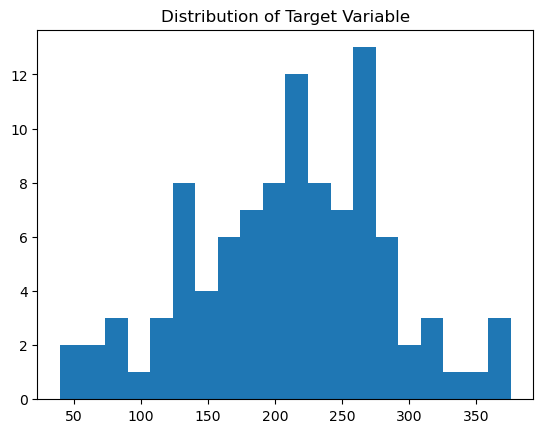

In [43]:
import matplotlib.pyplot as plt

plt.hist(y, bins=20)
plt.title("Distribution of Target Variable")
plt.show()

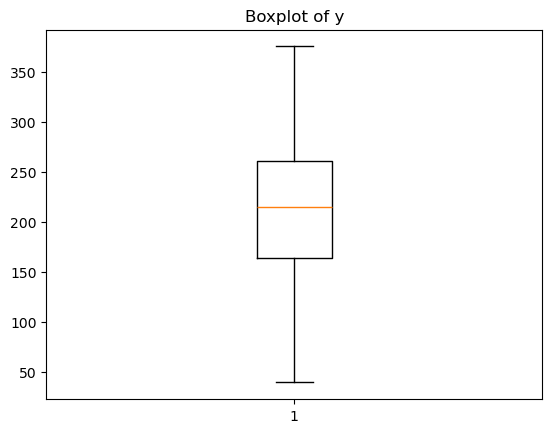

In [44]:
plt.boxplot(y)
plt.title("Boxplot of y")
plt.show()

In [45]:
y.describe()

count    100.000000
mean     211.521238
std       72.476499
min       39.702218
25%      163.757582
50%      215.257947
75%      260.907758
max      375.823073
Name: y, dtype: float64

Get missing value percentage for each variable

In [46]:
train.isna().sum().sort_values(ascending=False).head(10)

x_85    27
x_12    24
C_01    22
x_65    22
C_02    22
C_03    22
C_05    22
C_04    22
x_20    21
x_02    21
dtype: int64

Define x and y

Missing value visualization

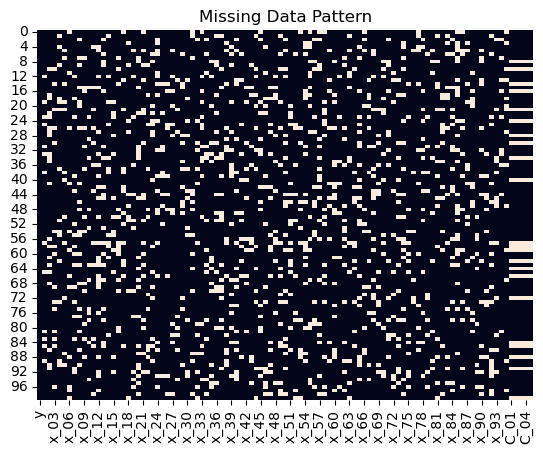

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(train.isnull(), cbar=False)
plt.title("Missing Data Pattern")
plt.show()

Check C01 to C05

In [48]:
for col in ["C_01", "C_02", "C_03", "C_04", "C_05"]:
    print(col, train[col].nunique())

C_01 5
C_02 1
C_03 5
C_04 5
C_05 5


Check further about C02

In [49]:
train["C_02"].value_counts()


C_02
72.0    78
Name: count, dtype: int64

In [50]:
train["C_02"].var()

0.0

In [51]:
constant_cols = train.columns[train.nunique() == 1]
print(constant_cols)

Index(['C_02'], dtype='object')


Drop C_02

In [52]:
train = train.drop(columns=["C_02"])
test = test.drop(columns=["C_02"])

Recreate

In [53]:
X = train.drop(columns=["y"])
y = train["y"]

Split Columns

In [54]:
num_cols = [col for col in X.columns if col.startswith("x_")]
cat_cols = [col for col in X.columns if col.startswith("C_")]

Compute skewness

In [55]:
skewness = X[num_cols].skew()

In [56]:
symmetric = skewness[abs(skewness) < 0.5].index
moderate = skewness[(abs(skewness) >= 0.5) & (abs(skewness) < 1)].index
highly_skewed = skewness[abs(skewness) >= 1].index

print("Symmetric:", len(symmetric))
print("Moderately skewed:", len(moderate))
print("Highly skewed:", len(highly_skewed))

Symmetric: 90
Moderately skewed: 5
Highly skewed: 0


Replace by mean:Skewness analysis showed that 90% of the features were approximately symmetric, while only a small number exhibited moderate skewness. Since no variables were highly skewed, mean imputation was applied consistently across all numerical features to ensure stability and simplicity in a high-dimensional setting.

In [57]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="mean")

X_num = num_imputer.fit_transform(X[num_cols])
X_test_num = num_imputer.transform(test[num_cols])

Treat Categorical variables

In [58]:
cat_imputer = SimpleImputer(strategy="most_frequent")

X_cat = cat_imputer.fit_transform(X[cat_cols])
X_test_cat = cat_imputer.transform(test[cat_cols])

Combine both numeric and categoric

In [59]:
import numpy as np

X_imputed = np.hstack([X_num, X_cat])
X_test_imputed = np.hstack([X_test_num, X_test_cat])

Convert back to Data frame

In [60]:
import pandas as pd

X_imputed_df = pd.DataFrame(
    X_imputed,
    columns=num_cols + cat_cols
)

Correlation heatmap

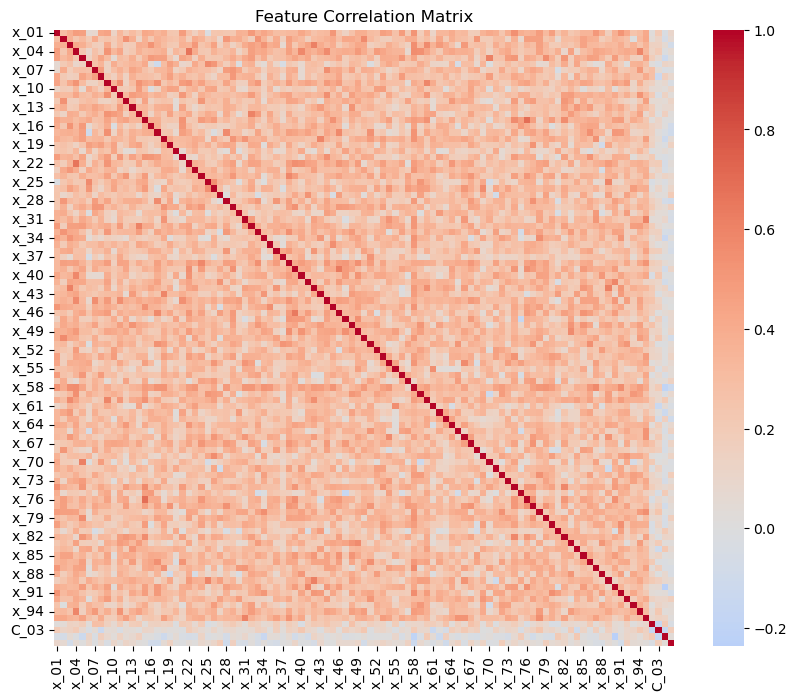

In [61]:
corr_matrix = X_imputed_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.savefig("Feature correlation Matrix.png")
plt.show()

Verify missing values are gone

In [62]:
X_imputed_df.isna().sum().sum()

np.int64(0)

Define CV and Alphas

K fold result for Ridge

In [63]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)
alphas = [0.01, 0.1, 1, 10, 100]

kfold_results = {}

for alpha in alphas:
    rmse_folds = []
    
    for train_idx, val_idx in cv.split(X_imputed_df):
        
        # Split data
        X_train = X_imputed_df.iloc[train_idx]
        X_val = X_imputed_df.iloc[val_idx]
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]
        
        # Scale (NO LEAKAGE)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        # Train model
        model = Ridge(alpha=alpha)
        model.fit(X_train_scaled, y_train)
        
        # Predict
        y_pred = model.predict(X_val_scaled)
        
        # RMSE
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        rmse_folds.append(rmse)
    
    kfold_results[alpha] = np.mean(rmse_folds)

best_alpha_kfold = min(kfold_results, key=kfold_results.get)
rmse_ridge = kfold_results[best_alpha_kfold]

print("K-Fold Best alpha:", best_alpha_kfold)
print("K-Fold RMSE:", rmse_ridge)

K-Fold Best alpha: 1
K-Fold RMSE: 30.019428395031277


Nested CV Ridge

In [64]:
alphas = [0.01, 0.1, 1, 10, 100]

outer_cv = KFold(n_splits=10, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

outer_rmse_ridge = []
chosen_alphas = []

for train_idx, test_idx in outer_cv.split(X_imputed_df):
    
    # Outer split
    X_train_outer = X_imputed_df.iloc[train_idx]
    y_train_outer = y.iloc[train_idx]
    
    X_test_outer = X_imputed_df.iloc[test_idx]
    y_test_outer = y.iloc[test_idx]
    
    # ----- INNER CV: find best alpha -----
    inner_results = {}
    
    for alpha in alphas:
        rmse_inner = []
        
        for train_i, val_i in inner_cv.split(X_train_outer):
            
            X_train_inner = X_train_outer.iloc[train_i]
            X_val_inner = X_train_outer.iloc[val_i]
            
            y_train_inner = y_train_outer.iloc[train_i]
            y_val_inner = y_train_outer.iloc[val_i]
            
            # Scale properly
            scaler = StandardScaler()
            X_train_inner_scaled = scaler.fit_transform(X_train_inner)
            X_val_inner_scaled = scaler.transform(X_val_inner)
            
            model = Ridge(alpha=alpha)
            model.fit(X_train_inner_scaled, y_train_inner)
            
            y_pred_inner = model.predict(X_val_inner_scaled)
            rmse_inner.append(np.sqrt(mean_squared_error(y_val_inner, y_pred_inner)))
        
        inner_results[alpha] = np.mean(rmse_inner)
    
    # Best alpha from inner CV
    best_alpha_inner = min(inner_results, key=inner_results.get)
    chosen_alphas.append(best_alpha_inner)
    
    # ----- Train on outer training set -----
    scaler = StandardScaler()
    X_train_outer_scaled = scaler.fit_transform(X_train_outer)
    X_test_outer_scaled = scaler.transform(X_test_outer)
    
    final_model = Ridge(alpha=best_alpha_inner)
    final_model.fit(X_train_outer_scaled, y_train_outer)
    
    # Evaluate on outer test fold
    y_pred_outer = final_model.predict(X_test_outer_scaled)
    rmse_outer = np.sqrt(mean_squared_error(y_test_outer, y_pred_outer))
    
    outer_rmse_ridge.append(rmse_outer)

rmse_nested = np.mean(outer_rmse_ridge)

print("Nested CV RMSE (mean):", np.mean(outer_rmse_ridge))
print("Nested CV RMSE (std):", np.std(outer_rmse_ridge))
print("Chosen alphas per fold:", chosen_alphas)

Nested CV RMSE (mean): 31.987622189890306
Nested CV RMSE (std): 6.152459237782443
Chosen alphas per fold: [10, 10, 1, 10, 1, 1, 1, 1, 10, 10]


LASSO

In [65]:
from sklearn.linear_model import Lasso

alphas = [0.01, 0.1, 0.5, 1, 5, 10]
lasso_results = {}

for alpha in alphas:
    rmse_folds = []
    
    for train_idx, val_idx in cv.split(X_imputed_df):
        
        X_train = X_imputed_df.iloc[train_idx]
        X_val = X_imputed_df.iloc[val_idx]
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]
        
        # Scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        model = Lasso(alpha=alpha, max_iter=50000)
        model.fit(X_train_scaled, y_train)
        
        y_pred = model.predict(X_val_scaled)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        
        rmse_folds.append(rmse)
    
    lasso_results[alpha] = np.mean(rmse_folds)

best_alpha_lasso = min(lasso_results, key=lasso_results.get)
rmse_lasso = lasso_results[best_alpha_lasso]

print("LASSO best alpha:", best_alpha_lasso)
print("LASSO RMSE:", rmse_lasso)

LASSO best alpha: 0.5
LASSO RMSE: 31.334355942108488


In [66]:
from sklearn.linear_model import Lasso

alphas = [0.01, 0.1, 0.5, 1, 5, 10]

outer_cv = KFold(n_splits=10, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

outer_rmse_lasso = []
chosen_alphas = []

for train_idx, test_idx in outer_cv.split(X_imputed_df):
    
    # ----- OUTER SPLIT -----
    X_train_outer = X_imputed_df.iloc[train_idx]
    y_train_outer = y.iloc[train_idx]
    
    X_test_outer = X_imputed_df.iloc[test_idx]
    y_test_outer = y.iloc[test_idx]
    
    # ----- INNER CV: find best alpha -----
    inner_results = {}
    
    for alpha in alphas:
        rmse_inner = []
        
        for train_i, val_i in inner_cv.split(X_train_outer):
            
            X_train_inner = X_train_outer.iloc[train_i]
            X_val_inner = X_train_outer.iloc[val_i]
            
            y_train_inner = y_train_outer.iloc[train_i]
            y_val_inner = y_train_outer.iloc[val_i]
            
            # Scaling
            scaler = StandardScaler()
            X_train_inner_scaled = scaler.fit_transform(X_train_inner)
            X_val_inner_scaled = scaler.transform(X_val_inner)
            
            model = Lasso(alpha=alpha, max_iter=50000)
            model.fit(X_train_inner_scaled, y_train_inner)
            
            y_pred_inner = model.predict(X_val_inner_scaled)
            rmse_inner.append(np.sqrt(mean_squared_error(y_val_inner, y_pred_inner)))
        
        inner_results[alpha] = np.mean(rmse_inner)
    
    # Best alpha from inner CV
    best_alpha_inner = min(inner_results, key=inner_results.get)
    chosen_alphas.append(best_alpha_inner)
    
    # ----- TRAIN FINAL MODEL ON OUTER TRAIN -----
    scaler = StandardScaler()
    X_train_outer_scaled = scaler.fit_transform(X_train_outer)
    X_test_outer_scaled = scaler.transform(X_test_outer)
    
    final_model = Lasso(alpha=best_alpha_inner, max_iter=50000)
    final_model.fit(X_train_outer_scaled, y_train_outer)
    
    # ----- EVALUATE ON OUTER TEST -----
    y_pred_outer = final_model.predict(X_test_outer_scaled)
    rmse_outer = np.sqrt(mean_squared_error(y_test_outer, y_pred_outer))
    
    outer_rmse_lasso.append(rmse_outer)

# Final performance
print("Nested CV RMSE (mean):", np.mean(outer_rmse_lasso))
print("Nested CV RMSE (std):", np.std(outer_rmse_lasso))
print("Chosen alphas per fold:", chosen_alphas)

Nested CV RMSE (mean): 31.714010087210642
Nested CV RMSE (std): 5.096169359007038
Chosen alphas per fold: [1, 0.5, 0.5, 5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]


Elastic Net

K fold

In [67]:
from sklearn.linear_model import ElasticNet

alphas = [0.01, 0.1, 0.5, 1, 5]
l1_ratios = [0.1, 0.5, 0.7, 0.9]

cv = KFold(n_splits=10, shuffle=True, random_state=42)

enet_results = {}

for alpha in alphas:
    for l1_ratio in l1_ratios:
        
        rmse_folds = []
        
        for train_idx, val_idx in cv.split(X_imputed_df):
            
            X_train = X_imputed_df.iloc[train_idx]
            X_val = X_imputed_df.iloc[val_idx]
            y_train = y.iloc[train_idx]
            y_val = y.iloc[val_idx]
            
            # Scaling
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            
            model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=50000)
            model.fit(X_train_scaled, y_train)
            
            y_pred = model.predict(X_val_scaled)
            rmse = np.sqrt(mean_squared_error(y_val, y_pred))
            
            rmse_folds.append(rmse)
        
        enet_results[(alpha, l1_ratio)] = np.mean(rmse_folds)

# Best combination
best_params = min(enet_results, key=enet_results.get)
best_alpha, best_l1 = best_params
rmse_enet = enet_results[best_params]

print("Best alpha:", best_alpha)
print("Best l1_ratio:", best_l1)
print("RMSE:", rmse_enet)

Best alpha: 0.1
Best l1_ratio: 0.7
RMSE: 29.275534520264294


Nested CV for Elastic Net

In [68]:
outer_cv = KFold(n_splits=10, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

outer_rmse_enet = []
chosen_params = []

for train_idx, test_idx in outer_cv.split(X_imputed_df):
    
    # ----- OUTER SPLIT -----
    X_train_outer = X_imputed_df.iloc[train_idx]
    y_train_outer = y.iloc[train_idx]
    
    X_test_outer = X_imputed_df.iloc[test_idx]
    y_test_outer = y.iloc[test_idx]
    
    # ----- INNER CV -----
    inner_results = {}
    
    for alpha in alphas:
        for l1_ratio in l1_ratios:
            
            rmse_inner = []
            
            for train_i, val_i in inner_cv.split(X_train_outer):
                
                X_train_inner = X_train_outer.iloc[train_i]
                X_val_inner = X_train_outer.iloc[val_i]
                
                y_train_inner = y_train_outer.iloc[train_i]
                y_val_inner = y_train_outer.iloc[val_i]
                
                # Scaling
                scaler = StandardScaler()
                X_train_inner_scaled = scaler.fit_transform(X_train_inner)
                X_val_inner_scaled = scaler.transform(X_val_inner)
                
                model = ElasticNet(
                    alpha=alpha,
                    l1_ratio=l1_ratio,
                    max_iter=50000
                )
                model.fit(X_train_inner_scaled, y_train_inner)
                
                y_pred_inner = model.predict(X_val_inner_scaled)
                rmse_inner.append(
                    np.sqrt(mean_squared_error(y_val_inner, y_pred_inner))
                )
            
            inner_results[(alpha, l1_ratio)] = np.mean(rmse_inner)
    
    # Best params
    best_params_inner = min(inner_results, key=inner_results.get)
    best_alpha, best_l1 = best_params_inner
    chosen_params.append(best_params_inner)
    
    # ----- TRAIN FINAL MODEL -----
    scaler = StandardScaler()
    X_train_outer_scaled = scaler.fit_transform(X_train_outer)
    X_test_outer_scaled = scaler.transform(X_test_outer)
    
    final_model = ElasticNet(
        alpha=best_alpha,
        l1_ratio=best_l1,
        max_iter=50000
    )
    final_model.fit(X_train_outer_scaled, y_train_outer)
    
    # Evaluate
    y_pred_outer = final_model.predict(X_test_outer_scaled)
    rmse_outer = np.sqrt(mean_squared_error(y_test_outer, y_pred_outer))
    
    outer_rmse_enet.append(rmse_outer)

# Final results
print("Nested CV RMSE (mean):", np.mean(outer_rmse_enet))
print("Nested CV RMSE (std):", np.std(outer_rmse_enet))
print("Chosen params per fold:", chosen_params)

Nested CV RMSE (mean): 31.76109199762002
Nested CV RMSE (std): 6.637065495648954
Chosen params per fold: [(0.5, 0.9), (0.5, 0.9), (0.1, 0.9), (0.1, 0.5), (0.1, 0.7), (0.1, 0.9), (0.1, 0.9), (0.1, 0.7), (0.5, 0.9), (0.5, 0.9)]


Random Forest

K-Fold

In [69]:
from sklearn.ensemble import RandomForestRegressor

n_estimators_list = [100, 200]
max_depth_list = [None, 10, 20]
min_samples_split_list = [2, 5]

cv = KFold(n_splits=10, shuffle=True, random_state=42)

rf_results = {}

for n in n_estimators_list:
    for depth in max_depth_list:
        for min_split in min_samples_split_list:
            
            rmse_folds = []
            
            for train_idx, val_idx in cv.split(X_imputed_df):
                
                X_train = X_imputed_df.iloc[train_idx]
                X_val = X_imputed_df.iloc[val_idx]
                y_train = y.iloc[train_idx]
                y_val = y.iloc[val_idx]
                
                model = RandomForestRegressor(
                    n_estimators=n,
                    max_depth=depth,
                    min_samples_split=min_split,
                    random_state=42,
                    n_jobs=-1
                )
                
                model.fit(X_train, y_train)
                y_pred = model.predict(X_val)
                
                rmse = np.sqrt(mean_squared_error(y_val, y_pred))
                rmse_folds.append(rmse)
            
            rf_results[(n, depth, min_split)] = np.mean(rmse_folds)

rmse_rf = min(rf_results, key=rf_results.get)
print("Best RF params:", rmse_rf)
print("Best RF RMSE:", rf_results[rmse_rf])

Best RF params: (200, 10, 5)
Best RF RMSE: 43.75277609903233


Random Forest Nested

In [70]:
outer_cv = KFold(n_splits=10, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

outer_rmse_rf = []
chosen_params_rf = []

for train_idx, test_idx in outer_cv.split(X_imputed_df):
    
    X_train_outer = X_imputed_df.iloc[train_idx]
    y_train_outer = y.iloc[train_idx]
    
    X_test_outer = X_imputed_df.iloc[test_idx]
    y_test_outer = y.iloc[test_idx]
    
    inner_results = {}
    
    for n in n_estimators_list:
        for depth in max_depth_list:
            for min_split in min_samples_split_list:
                
                rmse_inner = []
                
                for train_i, val_i in inner_cv.split(X_train_outer):
                    
                    X_train_inner = X_train_outer.iloc[train_i]
                    X_val_inner = X_train_outer.iloc[val_i]
                    
                    y_train_inner = y_train_outer.iloc[train_i]
                    y_val_inner = y_train_outer.iloc[val_i]
                    
                    model = RandomForestRegressor(
                        n_estimators=n,
                        max_depth=depth,
                        min_samples_split=min_split,
                        random_state=42,
                        n_jobs=-1
                    )
                    
                    model.fit(X_train_inner, y_train_inner)
                    y_pred_inner = model.predict(X_val_inner)
                    
                    rmse_inner.append(
                        np.sqrt(mean_squared_error(y_val_inner, y_pred_inner))
                    )
                
                inner_results[(n, depth, min_split)] = np.mean(rmse_inner)
    
    best_params = min(inner_results, key=inner_results.get)
    chosen_params_rf.append(best_params)
    
    n_best, depth_best, split_best = best_params
    
    final_model = RandomForestRegressor(
        n_estimators=n_best,
        max_depth=depth_best,
        min_samples_split=split_best,
        random_state=42,
        n_jobs=-1
    )
    
    final_model.fit(X_train_outer, y_train_outer)
    y_pred_outer = final_model.predict(X_test_outer)
    
    rmse_outer = np.sqrt(mean_squared_error(y_test_outer, y_pred_outer))
    outer_rmse_rf.append(rmse_outer)

print("RF Nested CV RMSE:", np.mean(outer_rmse_rf))

RF Nested CV RMSE: 43.51002938330168


Gradient Boosting K-fold

In [71]:
from sklearn.ensemble import GradientBoostingRegressor

n_estimators_list = [100, 200]
learning_rates = [0.01, 0.1]
max_depth_list = [3, 5]

gbr_results = {}

for n in n_estimators_list:
    for lr in learning_rates:
        for depth in max_depth_list:
            
            rmse_folds = []
            
            for train_idx, val_idx in cv.split(X_imputed_df):
                
                X_train = X_imputed_df.iloc[train_idx]
                X_val = X_imputed_df.iloc[val_idx]
                y_train = y.iloc[train_idx]
                y_val = y.iloc[val_idx]
                
                model = GradientBoostingRegressor(
                    n_estimators=n,
                    learning_rate=lr,
                    max_depth=depth,
                    random_state=42
                )
                
                model.fit(X_train, y_train)
                y_pred = model.predict(X_val)
                
                rmse_folds.append(
                    np.sqrt(mean_squared_error(y_val, y_pred))
                )
            
            gbr_results[(n, lr, depth)] = np.mean(rmse_folds)

rmse_gbr = min(gbr_results, key=gbr_results.get)
print("Best GBR params:", rmse_gbr)
print("Best GBR RMSE:", gbr_results[rmse_gbr])

Best GBR params: (200, 0.1, 3)
Best GBR RMSE: 40.92438796030133


Nested CV Gradient Boost

In [72]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

# Hyperparameter grid
n_estimators_list = [100, 200]
learning_rates = [0.01, 0.1]
max_depth_list = [3, 5]

outer_cv = KFold(n_splits=10, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

outer_rmse_gbr = []
chosen_params_gbr = []

for train_idx, test_idx in outer_cv.split(X_imputed_df):
    
    # ----- OUTER SPLIT -----
    X_train_outer = X_imputed_df.iloc[train_idx]
    y_train_outer = y.iloc[train_idx]
    
    X_test_outer = X_imputed_df.iloc[test_idx]
    y_test_outer = y.iloc[test_idx]
    
    # ----- INNER CV (hyperparameter tuning) -----
    inner_results = {}
    
    for n in n_estimators_list:
        for lr in learning_rates:
            for depth in max_depth_list:
                
                rmse_inner = []
                
                for train_i, val_i in inner_cv.split(X_train_outer):
                    
                    X_train_inner = X_train_outer.iloc[train_i]
                    X_val_inner = X_train_outer.iloc[val_i]
                    
                    y_train_inner = y_train_outer.iloc[train_i]
                    y_val_inner = y_train_outer.iloc[val_i]
                    
                    model = GradientBoostingRegressor(
                        n_estimators=n,
                        learning_rate=lr,
                        max_depth=depth,
                        random_state=42
                    )
                    
                    model.fit(X_train_inner, y_train_inner)
                    y_pred_inner = model.predict(X_val_inner)
                    
                    rmse_inner.append(
                        np.sqrt(mean_squared_error(y_val_inner, y_pred_inner))
                    )
                
                inner_results[(n, lr, depth)] = np.mean(rmse_inner)
    
    # Best hyperparameters from inner CV
    best_params = min(inner_results, key=inner_results.get)
    chosen_params_gbr.append(best_params)
    
    n_best, lr_best, depth_best = best_params
    
    # ----- TRAIN FINAL MODEL ON OUTER TRAIN -----
    final_model = GradientBoostingRegressor(
        n_estimators=n_best,
        learning_rate=lr_best,
        max_depth=depth_best,
        random_state=42
    )
    
    final_model.fit(X_train_outer, y_train_outer)
    
    # ----- EVALUATE ON OUTER TEST -----
    y_pred_outer = final_model.predict(X_test_outer)
    rmse_outer = np.sqrt(mean_squared_error(y_test_outer, y_pred_outer))
    
    outer_rmse_gbr.append(rmse_outer)

# Final performance
print("Gradient Boosting Nested CV RMSE (mean):", np.mean(outer_rmse_gbr))
print("Gradient Boosting Nested CV RMSE (std):", np.std(outer_rmse_gbr))
print("Chosen params per fold:", chosen_params_gbr)

Gradient Boosting Nested CV RMSE (mean): 40.92438796030133
Gradient Boosting Nested CV RMSE (std): 8.547324471433686
Chosen params per fold: [(200, 0.1, 3), (200, 0.1, 3), (200, 0.1, 3), (200, 0.1, 3), (200, 0.1, 3), (200, 0.1, 3), (200, 0.1, 3), (200, 0.1, 3), (200, 0.1, 3), (200, 0.1, 3)]


In [73]:
import pandas as pd
import numpy as np

# Create comparison table
results_df = pd.DataFrame({
    "Model": [
        "Ridge",
        "Lasso",
        "ElasticNet",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "K-Fold RMSE": [
        rmse_ridge,
        rmse_lasso,
        rmse_enet,
        rf_results[rmse_rf],
        gbr_results[rmse_gbr]
    ],
    
    "Nested CV RMSE": [
        np.mean(outer_rmse_ridge),
        np.mean(outer_rmse_lasso),
        np.mean(outer_rmse_enet),
        np.mean(outer_rmse_rf),
        np.mean(outer_rmse_gbr)
    ]
})

print(results_df)

               Model  K-Fold RMSE  Nested CV RMSE
0              Ridge    30.019428       31.987622
1              Lasso    31.334356       31.714010
2         ElasticNet    29.275535       31.761092
3      Random Forest    43.752776       43.510029
4  Gradient Boosting    40.924388       40.924388


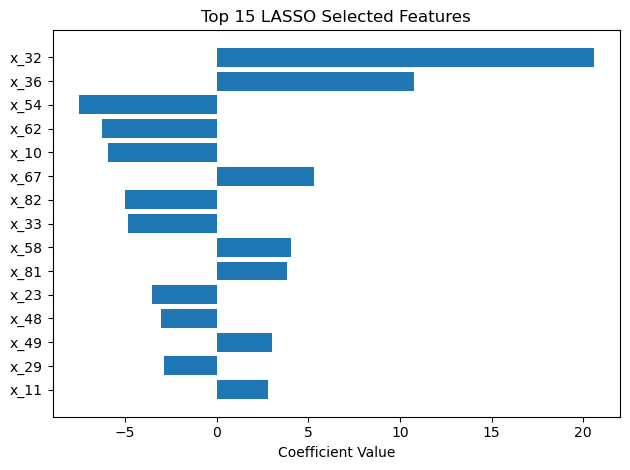

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Create dataframe
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lasso.coef_
})

# Keep only non-zero (selected features)
coef_df = coef_df[coef_df["Coefficient"] != 0]

# Sort by absolute importance
coef_df["AbsCoef"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="AbsCoef", ascending=False)

# Take top 15 (you can change this)
top_n = 15
top_features = coef_df.head(top_n)

# Plot
plt.figure()
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.gca().invert_yaxis()
plt.title(f"Top {top_n} LASSO Selected Features")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("lasso_top_features.png", dpi=300)
plt.show()

Extract removed features

In [81]:
# Selected features
selected = X_train.columns[lasso.coef_ != 0]

# Removed features
removed = X_train.columns[lasso.coef_ == 0]

print(f"Number of selected features: {len(selected)}")

selected_str = ", ".join(selected)
print(selected_str)

print(f"Number of removed features: {len(removed)}")
removed_str = ", ".join(removed)
print(removed_str)

Number of selected features: 74
x_01, x_02, x_03, x_04, x_05, x_07, x_08, x_10, x_11, x_12, x_13, x_14, x_15, x_16, x_17, x_18, x_19, x_21, x_22, x_23, x_25, x_26, x_27, x_28, x_29, x_30, x_32, x_33, x_35, x_36, x_39, x_40, x_41, x_42, x_43, x_44, x_45, x_46, x_48, x_49, x_51, x_53, x_54, x_55, x_56, x_58, x_60, x_62, x_63, x_65, x_67, x_71, x_72, x_74, x_75, x_77, x_78, x_79, x_80, x_81, x_82, x_84, x_85, x_86, x_89, x_91, x_92, x_93, x_94, x_95, C_01, C_03, C_04, C_05
Number of removed features: 25
x_06, x_09, x_20, x_24, x_31, x_34, x_37, x_38, x_47, x_50, x_52, x_57, x_59, x_61, x_64, x_66, x_68, x_69, x_70, x_73, x_76, x_83, x_87, x_88, x_90
